In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.lines as mlines
import seaborn as sns

from google.colab import drive


In [ ]:
drive.mount('/content/drive')
%cd "/content/drive/MyDrive/Colab Notebooks/Click Count"

Mounted at /content/drive
/content/drive/MyDrive/Colab Notebooks/Click Count


### Data Access
All data is stored on **Google Drive**. We mount the drive and import the required datasets directly into the environment.

In [ ]:
df = pd.read_csv('output/cleared_analyzed_data.csv')

df.head()

,date,file,name,clicks
0,2025-08-06,IMG-20250806-WA0003.jpg,Ahmad3,149
1,2025-08-03,IMG-20250803-WA0007.jpg,Ahmada,254
2,2025-08-06,IMG-20250806-WA0003.jpg,Ahmada,202
3,2025-08-03,IMG-20250803-WA0007.jpg,Ahmadg,37
4,2026-01-08,IMG-20260108-WA0006.jpg,Alexander3,312


### Data Structure
The dataset is presented in a tabular format and consists of the following fields:

*   **date:** The file creation date extracted from the filename.
*   **file:** The name of the original image from which the data was parsed.
*   **name:** The employee's name as recorded in the system.
*   **clicks:** The total number of barcode scans performed by the employee on that specific day.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2655 entries, 0 to 2654
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   date    2655 non-null   object
 1   file    2655 non-null   object
 2   name    2655 non-null   object
 3   clicks  2655 non-null   int64 
dtypes: int64(1), object(3)
memory usage: 83.1+ KB


The file contains 2655 lines.

In [ ]:
unique_names = df['name'].unique()
print("Unique names:")
print(unique_names)
print('-'*100)
print(f"Number of unique names: {len(unique_names)}")

Unique names:
['Ahmad3' 'Ahmada' 'Ahmadg' 'Alexander3' 'Amina' 'Amir3' 'ANAN'
 'Angelikas' 'Arago' 'Arego' 'Arkady3' 'ArtiomB' 'Ayub' 'Baruch' 'baruchk'
 'Ben' 'PHATHARAPHON3' 'Boleslav' 'bushra' 'Daniel' 'DanielL' 'DavidSch'
 'dimap' 'Dimav' 'DimaV' 'Eyob' 'Fernando' 'Gosha' 'hadash6' 'Haim'
 'Idank' 'IdoA' 'Igor3' 'Iraa' 'Itzhak3' 'Kirills' 'Kosta3' 'Kostantin3'
 'YuliaV' 'Leonid3' 'Liera' 'Lior3' 'liran' 'Vladimir3' 'marat' 'maratw'
 'Mohamad3' 'Nabaa6' 'nadims' 'Naor' 'OlgaA' 'Olgak' 'Oran' 'Oshri3'
 'PAITOON3' 'PATTAVEE3' 'peter3' 'PHANTASAK3' 'PHATTHAMA3' 'PHATTHANA3'
 'Phillip' 'Rami3' 'Refael3' 'Roman3' 'samuil3' 'Sanad3' 'SATIT3' 'SAVA3'
 'Shay' 'SOMSAK3' 'SQUSAK3' 'vladi' 'Vladimira' 'WANCHALERM3' 'Wiaam'
 'WORAWUT3' 'Yacov' 'yuliaK']
----------------------------------------------------------------------------------------------------
Number of unique names: 78


### Employee Verification
We verify unique entries in the **name** field. Each unique entry represents an individual employee identified by the system.

### Identifying and Filtering Latest Daily Data Versions

Since multiple snapshots were taken throughout a single day, and only the final one contains the most up-to-date cumulative data, additional transformations are required.

To achieve this, we will perform the following steps:
1.  **Date Conversion:** Convert the `date` column to a standard `datetime` format for efficient time-series manipulation.
2.  **Sequence Extraction:** Extract the numeric sequence number from the filenames (e.g., extracting `0003` from `IMG-20250806-WA0003.jpg`). This number serves as a version indicator.
3.  **Snapshot Identification:** For each unique date, identify the row corresponding to the file with the maximum sequence number. These rows will be marked as `True` in a new column named `is_latest_daily_version`.
4.  **Data Filtering:** Create a new DataFrame, `df_latest_daily_version`, containing only the rows flagged as `True` (the final/latest data version for each day).

In [ ]:
# Data Filtering by Daily Version
# 1. Convert the 'date' column to datetime format
df['date'] = pd.to_datetime(df['date'])

# 2. Extract the sequence number from the filename to determine the "version"
# For example, extract '0003' from 'IMG-20250806-WA0003.jpg' and convert to integer 3.
# This is a temporary column to help us identify the latest version.
df['file_sequence'] = df['file'].str.extract(r'WA(\d+)\.jpg').astype(int)

# 3. Find the maximum sequence number for each date.
# Use transform('max') to apply this value to all rows within each group.
max_sequence_per_date = df.groupby('date')['file_sequence'].transform('max')

# 4. Create a new column 'is_latest_daily_version' in the original DataFrame 'df'.
# It will contain True for all rows whose 'file_sequence' matches the maximum for their date.
df['is_latest_daily_version'] = (df['file_sequence'] == max_sequence_per_date)

# 5. Create a new DataFrame containing only the "latest version" records for each day.
# This fulfills the requirement to "keep only the actual/latest records".
df_latest_daily_version = df[df['is_latest_daily_version']].copy()

# Remove the temporary 'file_sequence' column from both DataFrames as it's no longer needed
df.drop(columns=['file_sequence'], inplace=True)
df_latest_daily_version.drop(columns=['file_sequence'], inplace=True)

# Display the first few rows of the original DataFrame with the new parameter
print("DataFrame with the added 'is_latest_daily_version' parameter:")
display(df.head())

# Display the first few rows of the new DataFrame filtered by the latest daily versions
print("\nDataFrame filtered by the latest daily versions:")
display(df_latest_daily_version.head())

DataFrame with the added 'is_latest_daily_version' parameter:


,date,file,name,clicks,is_latest_daily_version
0,2025-08-06,IMG-20250806-WA0003.jpg,Ahmad3,149,True
1,2025-08-03,IMG-20250803-WA0007.jpg,Ahmada,254,True
2,2025-08-06,IMG-20250806-WA0003.jpg,Ahmada,202,True
3,2025-08-03,IMG-20250803-WA0007.jpg,Ahmadg,37,True
4,2026-01-08,IMG-20260108-WA0006.jpg,Alexander3,312,True



DataFrame filtered by the latest daily versions:


,date,file,name,clicks,is_latest_daily_version
0,2025-08-06,IMG-20250806-WA0003.jpg,Ahmad3,149,True
1,2025-08-03,IMG-20250803-WA0007.jpg,Ahmada,254,True
2,2025-08-06,IMG-20250806-WA0003.jpg,Ahmada,202,True
3,2025-08-03,IMG-20250803-WA0007.jpg,Ahmadg,37,True
4,2026-01-08,IMG-20260108-WA0006.jpg,Alexander3,312,True


In [ ]:
df_latest_daily_version.sort_values(by='date', ascending=False).head()

,date,file,name,clicks,is_latest_daily_version
1155,2026-04-09,IMG-20260409-WA0000.jpg,maratw,5,True
2175,2026-04-09,IMG-20260409-WA0000.jpg,SOMSAK3,235,True
1903,2026-04-09,IMG-20260409-WA0000.jpg,SATIT3,243,True
2470,2026-04-09,IMG-20260409-WA0000.jpg,WORAWUT3,190,True
1528,2026-04-09,IMG-20260409-WA0000.jpg,PHANTASAK3,251,True


### 1. Full Timeline Performance

A complete historical overview of 'Roman3' click activity from the beginning of data collection: **July 2025 to April 2026**. The **Baseline** represents the minimum required daily click count (350 clicks).


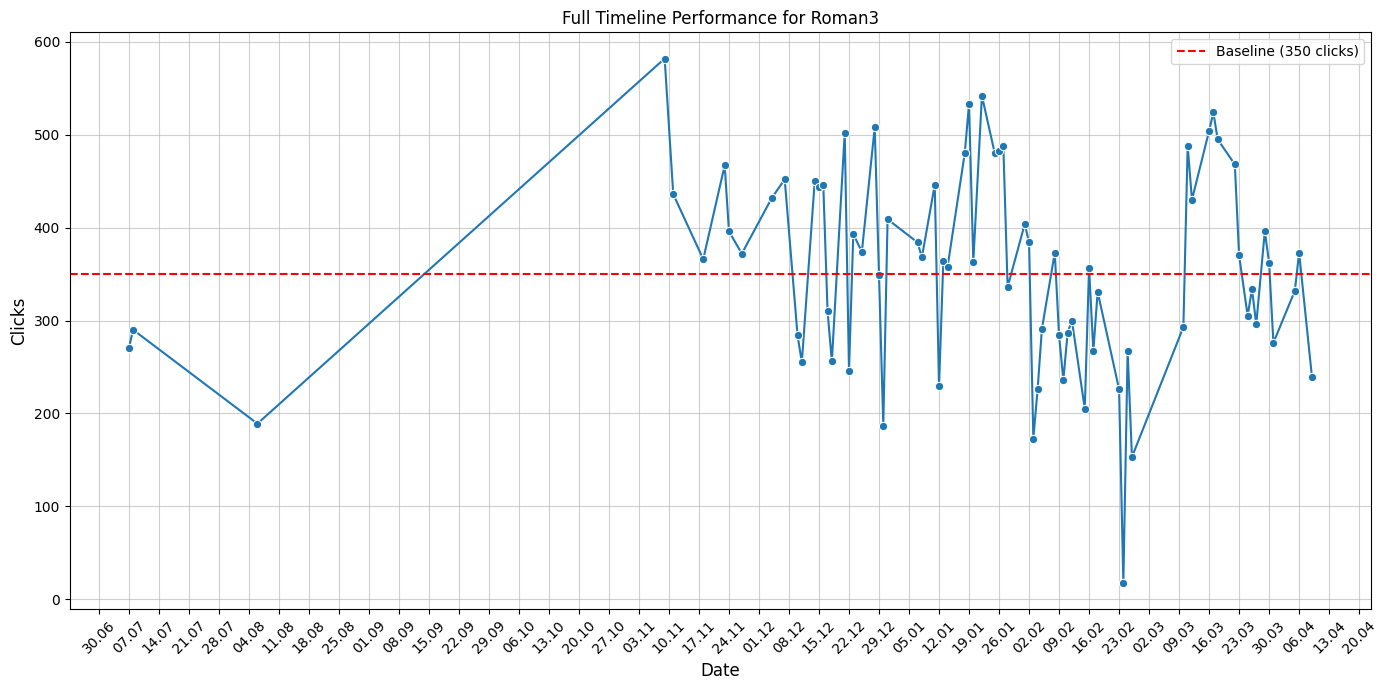

In [ ]:
# Filter data for name 'Roman3' from df_latest_daily_version
roman3_df = df_latest_daily_version[df_latest_daily_version['name'] == 'Roman3'].sort_values(by='date')

# Check if data exists for 'Roman3'
if not roman3_df.empty:
    plt.figure(figsize=(14, 7))
    sns.lineplot(x='date', y='clicks', data=roman3_df, marker='o')
    # --- UNIFIED GRID FORMAT ---
    # Major grid: Every 7 days (Mondays)
    plt.gca().xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO, interval=1))
    # Date format: Day.Month (e.g., 01.12)
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d.%m'))

    # Add a horizontal baseline at 350 clicks
    plt.axhline(y=350, color='r', linestyle='--', label='Baseline (350 clicks)')

    plt.title('Full Timeline Performance for Roman3')
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Clicks', fontsize=12)
    # Clean up grid lines to make them neat
    plt.grid(True, which='major', linestyle='-', alpha=0.6)
    plt.grid(True, which='minor', linestyle=':', alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.legend()
    plt.savefig('figures/fig_1.png')
    plt.show()
else:
    print("No data found for 'Roman3' in the filtered DataFrame.")

### 2. Focused Performance Analysis (Dec 2025 – April 2026)


Filtered view starting from December 2025 to ensure data density and better representativeness for current performance evaluation.

Additionally, a vertical line is added at **March 22, 2026**, marking the date 'Roman3' officially joined **Golf**.

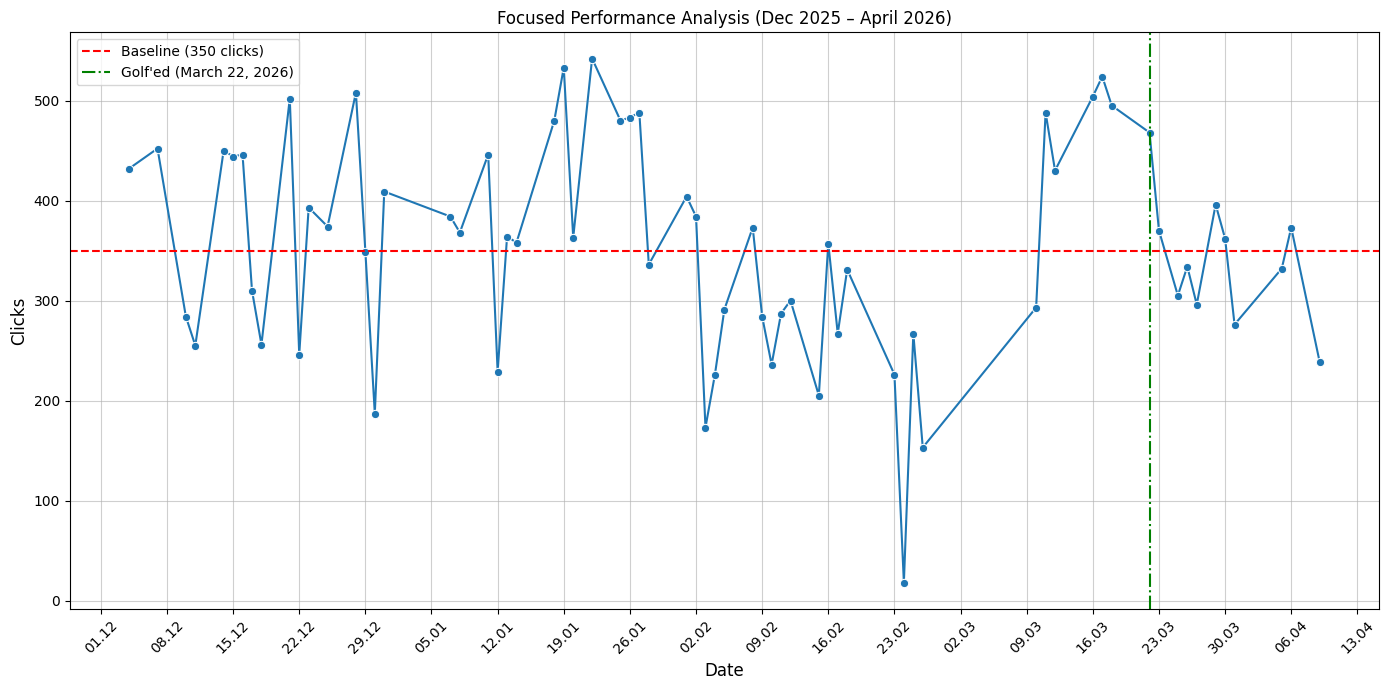

In [ ]:
# Filter data for name 'Roman3' from df_latest_daily_version starting from Dec 1, 2025
roman3_df = df_latest_daily_version[
    (df_latest_daily_version['name'] == 'Roman3') &
    (df_latest_daily_version['date'] >= '2025-12-01')
].sort_values(by='date')

# Check if data exists for 'Roman3'
if not roman3_df.empty:
    plt.figure(figsize=(14, 7))
    sns.lineplot(x='date', y='clicks', data=roman3_df, marker='o') # Add markers for each data point

    # --- UNIFIED GRID FORMAT ---
    # Major grid: Every 7 days (Mondays)
    plt.gca().xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO, interval=1))
    # Date format: Day.Month
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d.%m'))

    # Add a horizontal baseline at 350 clicks
    plt.axhline(y=350, color='r', linestyle='--', label='Baseline (350 clicks)')

    # Add a vertical line for March 22, 2026
    plt.axvline(x=pd.to_datetime('2026-03-22'), color='g', linestyle='-.', label="Golf'ed (March 22, 2026)")

    plt.title('Focused Performance Analysis (Dec 2025 – April 2026)')
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Clicks', fontsize=12)

    # Clean up grid lines to make them neat (according to the new standard)
    plt.grid(True, which='major', linestyle='-', alpha=0.6)
    plt.grid(True, which='minor', linestyle=':', alpha=0.3)

    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.savefig('figures/fig_2.png')
    plt.show()
else:
    print("No data found for 'Roman3' within the specified date range.")

### 3. Peer Benchmarking: 'Roman3' vs. Key Staff

Comparative analysis of 'Roman3' against selected colleagues ('DimaV', 'ArtiomB', 'Fernando') to establish relative performance levels. These employees were selected randomly for benchmarking purposes.

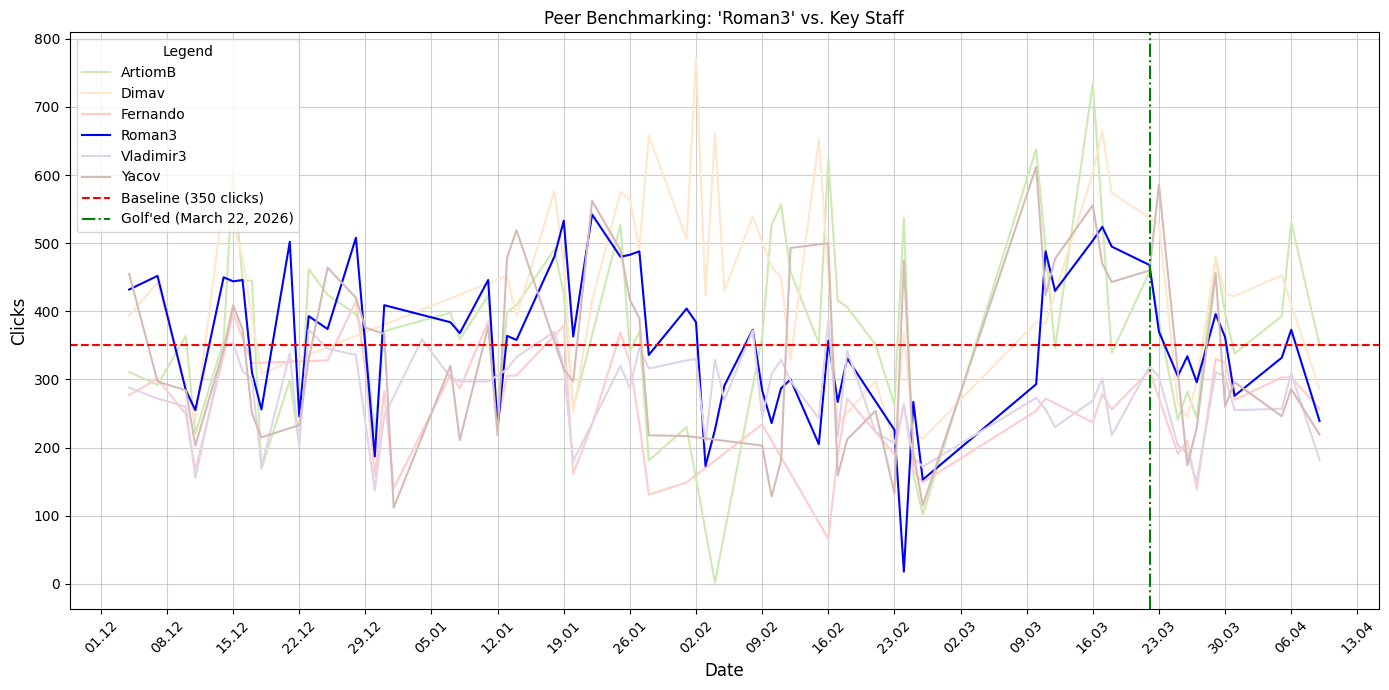

In [ ]:
# Define the list of names to plot
names_to_plot = ['Roman3', 'Dimav', 'ArtiomB', 'Fernando', 'Vladimir3', 'Yacov']

# Define a custom color palette with 'Roman3' in blue
custom_palette = {
    'Roman3': 'blue',         # Rich Blue (Royal Blue)
    'Dimav': '#ffe6cc',       # Light Orange (Pale Orange)
    'ArtiomB': '#cceab2',     # Light Green (Pale Green)
    'Fernando': '#ffcccc',    # Light Red (Soft Red/Pink)
    'Vladimir3': '#e1d3e8',   # Light Purple (Pale Purple)
    'Yacov': '#d6bab5'        # Light Brown (Pale Brown)
}

# Filter data for the specified names and period from df_latest_daily_version
multi_name_df = df_latest_daily_version[
    (df_latest_daily_version['name'].isin(names_to_plot)) &
    (df_latest_daily_version['date'] >= '2025-12-01')
].sort_values(by=['name', 'date'])

# Check if there is data for any of the names
if not multi_name_df.empty:
    plt.figure(figsize=(14, 7))
    sns.lineplot(x='date', y='clicks', hue='name', data=multi_name_df, palette=custom_palette)

    # --- UNIFIED GRID FORMAT ---
    # Major grid: Every 7 days (Mondays)
    plt.gca().xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO, interval=1))
    # Date format: Day.Month
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d.%m'))

    # Add horizontal line at 350 clicks
    plt.axhline(y=350, color='r', linestyle='--', label='Baseline (350 clicks)')

    # Add vertical line on March 22, 2026
    plt.axvline(x=pd.to_datetime('2026-03-22'), color='g', linestyle='-.', label="Golf'ed (March 22, 2026)")

    plt.title("Peer Benchmarking: 'Roman3' vs. Key Staff")
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Clicks', fontsize=12)

    # Clean up grid lines to make them neat
    plt.grid(True, which='major', linestyle='-', alpha=0.6)
    plt.grid(True, which='minor', linestyle=':', alpha=0.3)

    plt.xticks(rotation=45)
    plt.legend(title='Legend')
    plt.tight_layout()
    plt.savefig('figures/fig_3.png')
    plt.show()
else:
    print("No data found within the specified date range.")

### 4. Contextual Impact: SABON Launch & Geopolitical Events

Correlation between workload and external factors. This visualization highlights how specialized assignments (SABON) and regional instability (EPIC FURRY) influenced output.


*   **SABON:** Represents the period when **'Roman3'** was assigned to a newly launched department. Working in this department required significantly more focus, precision, and effort compared to standard operations.
*   **EPIC FURRY:** Marks the onset of active military operations in Israel and the USA against Iran. This geopolitical event had a substantial impact on overall business logistics and operations.

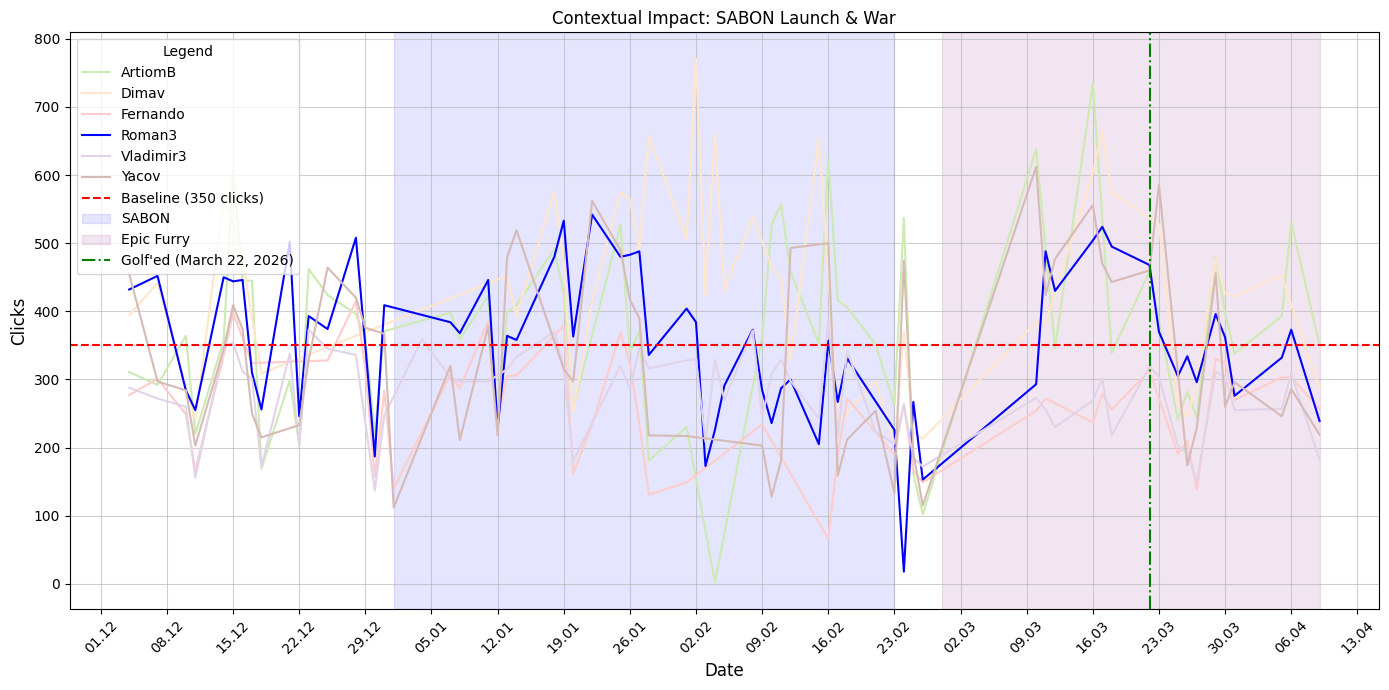

In [ ]:
# Filter data for the specified names and period from df_latest_daily_version
multi_name_df = df_latest_daily_version[
    (df_latest_daily_version['name'].isin(names_to_plot)) &
    (df_latest_daily_version['date'] >= '2025-12-01')
].sort_values(by=['name', 'date'])

# Check if there is data for any of the names
if not multi_name_df.empty:
    plt.figure(figsize=(14, 7))
    sns.lineplot(x='date', y='clicks', hue='name', data=multi_name_df, palette=custom_palette)

    # --- UNIFIED GRID FORMAT ---
    # Major grid: Every 7 days (Mondays)
    plt.gca().xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO, interval=1))
    # Date format: Day.Month
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d.%m'))

    # Add horizontal line at 350 clicks
    plt.axhline(y=350, color='r', linestyle='--', label='Baseline (350 clicks)')

    # Add two periods to the graph
    # SABON period: January 1st to February 23rd, 2026
    plt.axvspan(pd.to_datetime('2026-01-01'), pd.to_datetime('2026-02-23'), color='blue', alpha=0.1, label='SABON')
    # Epic Furry period: February 28th, 2026 to the latest date in the data
    plt.axvspan(pd.to_datetime('2026-02-28'), multi_name_df['date'].max(), color='purple', alpha=0.1, label='Epic Furry')

    # Add vertical line on March 22, 2026
    plt.axvline(x=pd.to_datetime('2026-03-22'), color='g', linestyle='-.', label="Golf'ed (March 22, 2026)")

    plt.title("Contextual Impact: SABON Launch & War")
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Clicks', fontsize=12)

    # Clean up grid lines to make them neat
    plt.grid(True, which='major', linestyle='-', alpha=0.6)
    plt.grid(True, which='minor', linestyle=':', alpha=0.3)

    plt.xticks(rotation=45)
    plt.legend(title='Legend')
    plt.tight_layout()
    plt.savefig('figures/fig_4.png')
    plt.show()
else:
    print("No data found for the specified names within the selected date range.")

### 5. Comparative Efficiency: 'Roman3' vs. New Onboarders (Thai Staff)

Description: Benchmarking 'Roman3' against the newly joined staff from Thailand to evaluate the efficiency of an experienced employee versus new arrivals.



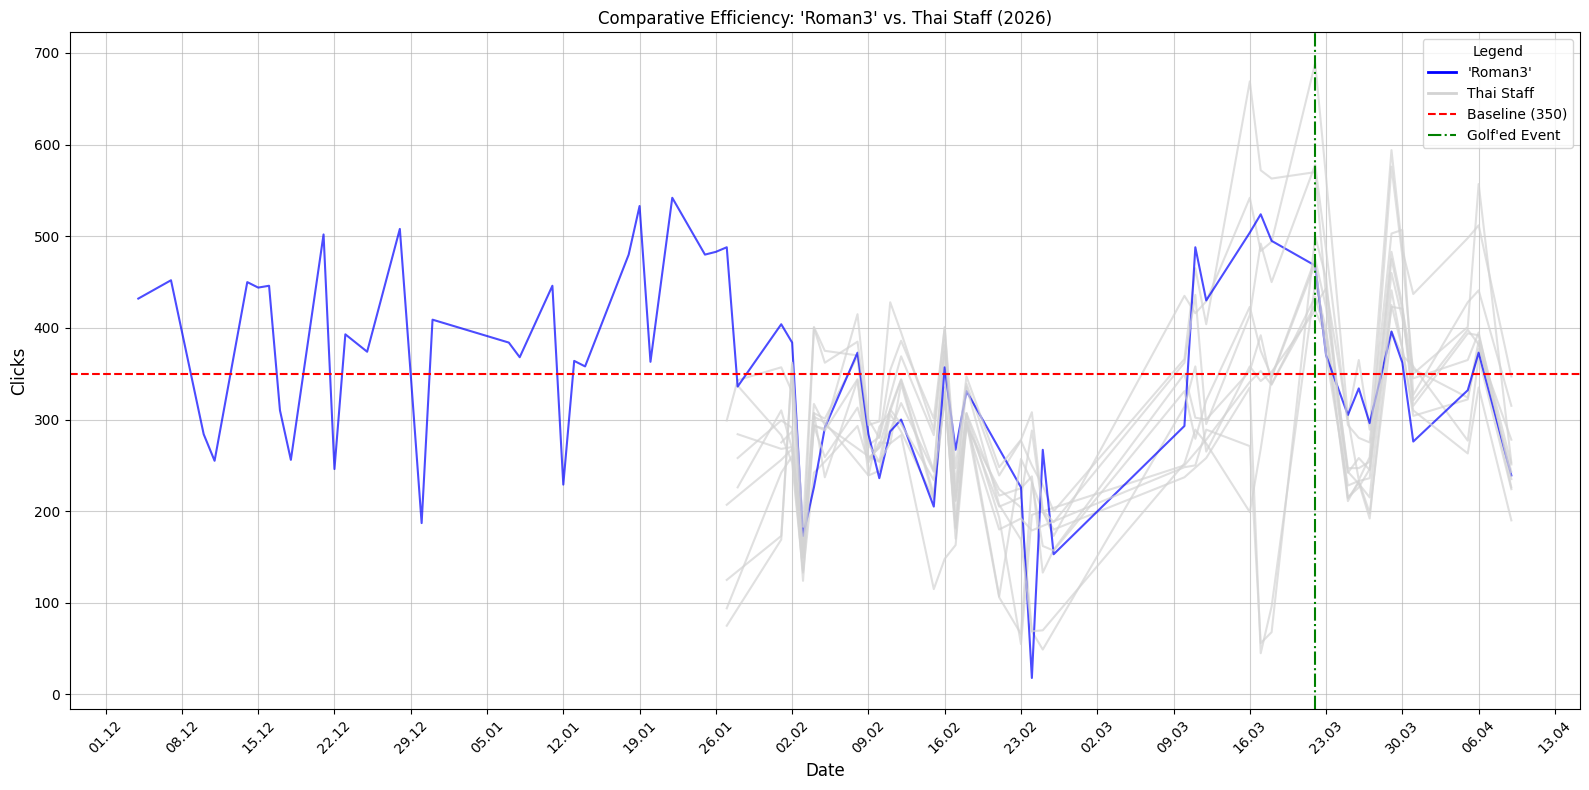

In [ ]:
# 1. Automatically detect Thai staff names (all uppercase), excluding SAVA3
# This ensures SAVA3 will not be included in the selection at all
thai_staff_names = [name for name in df_latest_daily_version['name'].unique()
                    if isinstance(name, str) and name.isupper() and name != 'SAVA3']

# 2. Form the list for filtering: only Roman3 and Thai staff
combined_names_to_plot = list(set(thai_staff_names + ['Roman3']))

# 3. Filter data for the 2026 period
multi_name_df_thai_caps = df_latest_daily_version[
    (df_latest_daily_version['name'].isin(combined_names_to_plot)) &
    (df_latest_daily_version['date'] >= '2025-12-01')
].sort_values(by=['name', 'date'])

if not multi_name_df_thai_caps.empty:
    plt.figure(figsize=(16, 8))

    # Color scheme: Roman3 is blue, others (Thai staff) are light grey
    custom_palette_mapping = {name: 'lightgrey' for name in multi_name_df_thai_caps['name'].unique()}
    if 'Roman3' in custom_palette_mapping:
        custom_palette_mapping['Roman3'] = 'blue'

    sns.lineplot(x='date', y='clicks', hue='name', data=multi_name_df_thai_caps,
                palette=custom_palette_mapping, alpha=0.7)

    # --- UNIFIED GRID FORMAT ---
    plt.gca().xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO, interval=1))
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d.%m'))

    # Baseline and Event lines
    plt.axhline(y=350, color='r', linestyle='--', label='Baseline (350 clicks)')
    plt.axvline(x=pd.to_datetime('2026-03-22'), color='g', linestyle='-.', label="Golf'ed (March 22, 2026)")

    plt.title("Comparative Efficiency: 'Roman3' vs. Thai Staff (2026)")
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Clicks', fontsize=12)

    # Grid styling
    plt.grid(True, which='major', linestyle='-', alpha=0.6)
    plt.grid(True, which='minor', linestyle=':', alpha=0.3)
    plt.xticks(rotation=45)

    # --- Manual Legend Creation ---
    legend_elements = []

    # Roman3
    if 'Roman3' in multi_name_df_thai_caps['name'].unique():
        legend_elements.append(mlines.Line2D([0], [0], color='blue', lw=2,  label="'Roman3'"))

    # Thai Staff Group
    legend_elements.append(mlines.Line2D([0], [0], color='lightgrey', lw=2,  label='Thai Staff'))

    # Technical Lines
    legend_elements.append(mlines.Line2D([0], [0], color='r', linestyle='--', label='Baseline (350)'))
    legend_elements.append(mlines.Line2D([0], [0], color='g', linestyle='-.', label="Golf'ed Event"))

    plt.legend(handles=legend_elements, title='Legend')

    plt.tight_layout()
    plt.savefig('figures/fig_5.png')
    plt.show()
else:
    print("No data found for the analysis.")

### 6. Overall Performance Distribution & Average Ranking

A ranking of all employees by their average click count. 'Roman3' is highlighted to show his standing relative to the company-wide 350-click baseline.

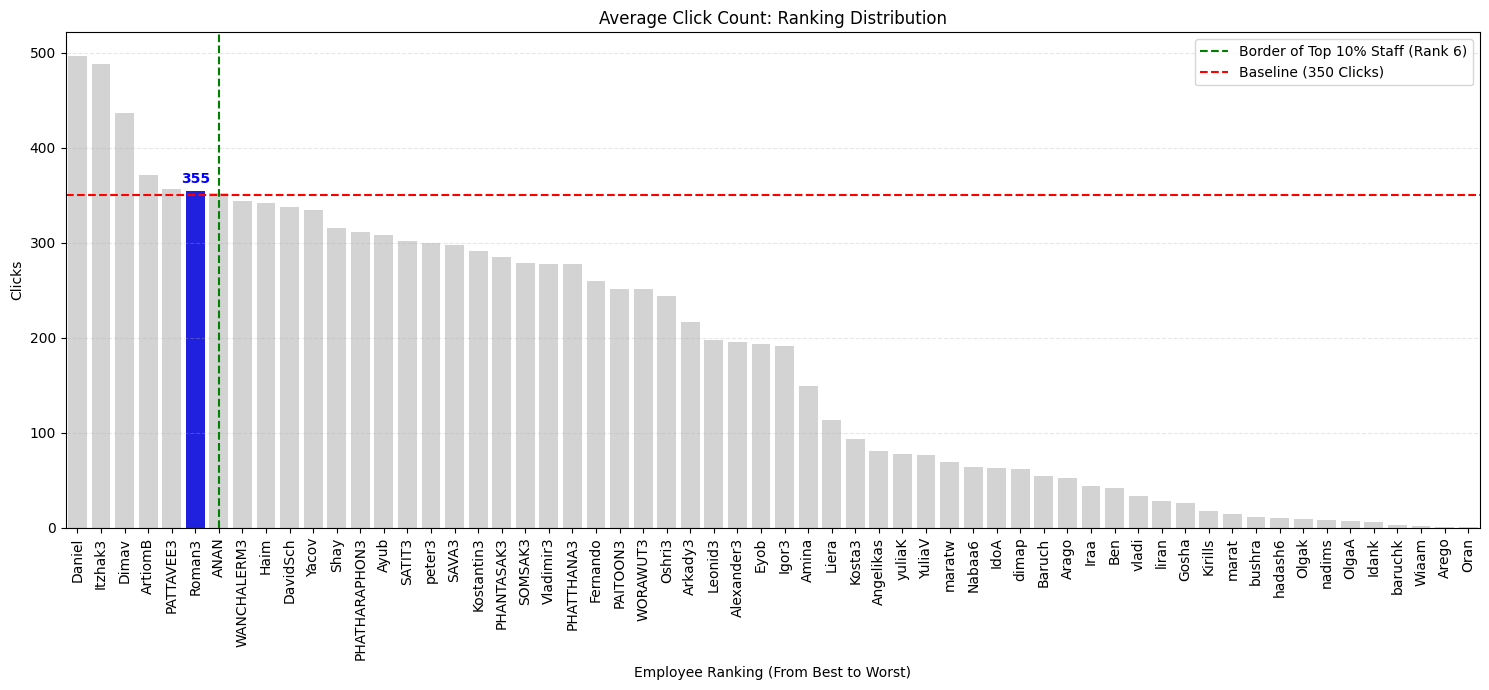

In [ ]:
# Filter data starting from December 2025
df_2026 = df_latest_daily_version[df_latest_daily_version['date'] >= '2025-12-01'].copy()

# Group by name and calculate the average click count
average_clicks_per_name = df_2026.groupby('name')['clicks'].mean().reset_index()

# Sort from highest to lowest (your ranking distribution)
average_clicks_per_name = average_clicks_per_name.sort_values(by='clicks', ascending=False).reset_index(drop=True)

# --- QUARTILE CALCULATION BY STAFF COUNT ---
total_staff = len(average_clicks_per_name)
top_25_percent_rank = int(total_staff * 0.10)
# top_50_percent_rank = int(total_staff * 0.50)

plt.figure(figsize=(15, 7))

# Colors: 'Roman3' is blue, everyone else is grey
colors = ['blue' if name == 'Roman3' else 'lightgrey' for name in average_clicks_per_name['name']]

sns.barplot(x='name', y='clicks', data=average_clicks_per_name, hue='name', palette=colors, legend=False)

# Vertical lines separating EMPLOYEES into groups
plt.axvline(x=top_25_percent_rank, color='green', linestyle='--', label=f'Border of Top 10% Staff (Rank {top_25_percent_rank})')
# plt.axvline(x=top_50_percent_rank, color='orange', linestyle='--', label='Median Staff (Rank ' + str(top_50_percent_rank) + ')')

# Horizontal Baseline line
plt.axhline(y=350, color='r', linestyle='--', label='Baseline (350 Clicks)')

plt.title('Average Click Count: Ranking Distribution')
plt.xlabel('Employee Ranking (From Best to Worst)')
plt.ylabel('Clicks')
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.3)

# Value label for Roman3
roman3_avg_clicks = average_clicks_per_name[average_clicks_per_name['name'] == 'Roman3']['clicks'].iloc[0]
x_roman3 = list(average_clicks_per_name['name']).index('Roman3')
plt.text(x_roman3, roman3_avg_clicks + 5, f'{roman3_avg_clicks:.0f}', ha='center', va='bottom', color='blue', fontweight='bold')

plt.legend()
plt.tight_layout()
plt.savefig('figures/fig_6.png')
plt.show()

### 7. 'Roman3' 7-Day Rolling Average vs. Company Average

This trend analysis compares 'Roman3's 7-day rolling average against the company-wide average to highlight long-term performance trends. The graph includes shaded regions for two major operational milestones: the launch of the new SABON department (blue) and a forced operational pause (purple). This overlay provides direct context on how workload spikes and external disruptions impacted both individual and team productivity.

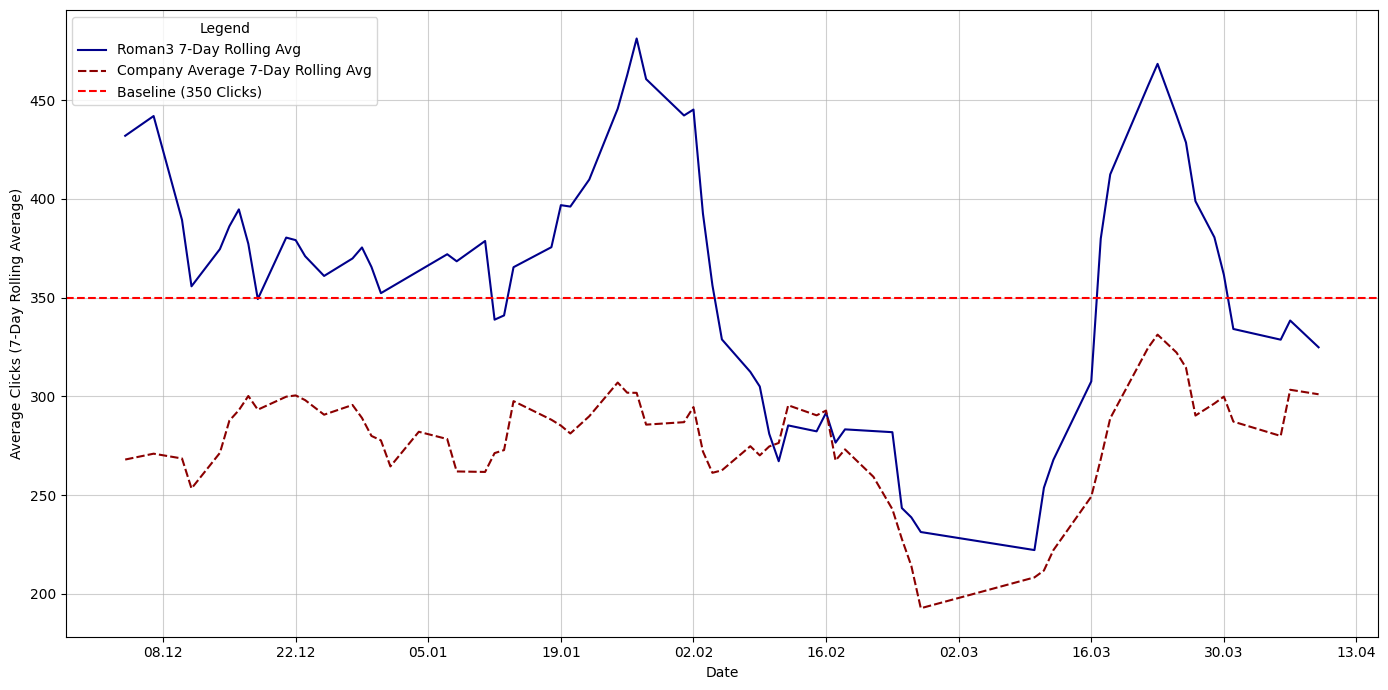

In [ ]:
# Filter data for Roman3 starting from December 2025
roman3_2026_df = df_latest_daily_version[
    (df_latest_daily_version['name'] == 'Roman3') &
    (df_latest_daily_version['date'] >= '2025-12-01')
].copy()

# Group by date and calculate the average click count for Roman3
roman3_average_clicks_per_day = roman3_2026_df.groupby('date')['clicks'].mean().reset_index()
# Calculate 7-day rolling average for Roman3
roman3_average_clicks_per_day['rolling_avg'] = roman3_average_clicks_per_day['clicks'].rolling(window=7, min_periods=1).mean()
roman3_average_clicks_per_day_ra = roman3_average_clicks_per_day.copy()
roman3_average_clicks_per_day_ra['clicks'] = roman3_average_clicks_per_day_ra['rolling_avg']
roman3_average_clicks_per_day_ra['type'] = 'Roman3 7-Day Rolling Avg'

# Extract data starting from December 2025 for the overall average
df_2026_daily_avg = df_latest_daily_version[df_latest_daily_version['date'] >= '2025-12-01'].copy()

# Group by date and calculate the company-wide average click count
overall_average_clicks_per_day = df_2026_daily_avg.groupby('date')['clicks'].mean().reset_index()
# Calculate 7-day rolling average for Company Average
overall_average_clicks_per_day['rolling_avg'] = overall_average_clicks_per_day['clicks'].rolling(window=7, min_periods=1).mean()
overall_average_clicks_per_day_ra = overall_average_clicks_per_day.copy()
overall_average_clicks_per_day_ra['clicks'] = overall_average_clicks_per_day_ra['rolling_avg']
overall_average_clicks_per_day_ra['type'] = 'Company Average 7-Day Rolling Avg'

# Combine only rolling average data for plotting
comparison_daily_df = pd.concat([
    roman3_average_clicks_per_day_ra[['date', 'clicks', 'type']],
    overall_average_clicks_per_day_ra[['date', 'clicks', 'type']]
])

plt.figure(figsize=(14, 7))
sns.lineplot(x='date', y='clicks', hue='type', data=comparison_daily_df, palette={'Roman3 7-Day Rolling Avg': 'darkblue', 'Company Average 7-Day Rolling Avg': 'darkred'}, style='type')

# --- UNIFIED GRID FORMAT ---
plt.gca().xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO, interval=2))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d.%m'))

# Horizontal Baseline line
plt.axhline(y=350, color='r', linestyle='--', label='Baseline (350 Clicks)')

# Add two periods to the graph
# SABON period: January 1st to February 23rd, 2026
plt.axvspan(pd.to_datetime('2026-01-01'), pd.to_datetime('2026-02-23'), color='blue', alpha=0.1, label='new department launch')
# Epic Furry period: February 28th, 2026 to the latest date in the data
plt.axvspan(pd.to_datetime('2026-02-28'), pd.to_datetime('2026-03-14'), color='purple', alpha=0.1, label='operational pause')


#plt.title("'Roman3' 7-Day Rolling Average vs. Company Average")
plt.xlabel('Date')
plt.ylabel('Average Clicks (7-Day Rolling Average)')

# Standardized grid styling
plt.grid(True, which='major', linestyle='-', alpha=0.6)
plt.grid(True, which='minor', linestyle=':', alpha=0.3)

plt.xticks(rotation=0)
plt.legend(title='Legend')
plt.tight_layout()
plt.savefig('figures/fig_7.png')
plt.show()

*'Roman3' 7-Day Rolling Average vs. Company Average*

### 8. Click Distribution for Top 5 Most Active Employees

This visualization shows the distribution of daily clicks for the top 5 employees, giving insights into their consistency and range of performance.

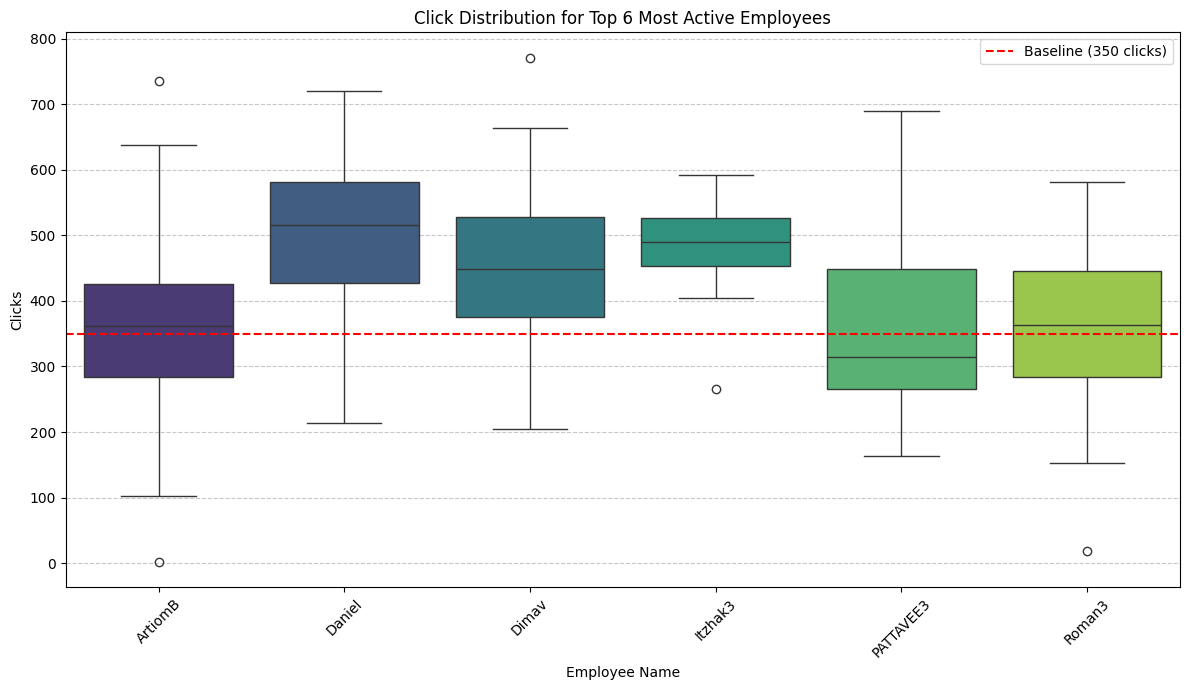

In [ ]:
# Get the top 6 most active employees based on average clicks
top_6_employees = average_clicks_per_name.head(6)['name'].tolist()

# Filter the df_latest_daily_version for these top 6 employees
top_6_df = df_latest_daily_version[
    df_latest_daily_version['name'].isin(top_6_employees)
].copy()

plt.figure(figsize=(12, 7))
sns.boxplot(x='name', y='clicks', data=top_6_df, hue='name', palette='viridis', legend=False)

plt.axhline(y=350, color='r', linestyle='--', label='Baseline (350 clicks)')

plt.title('Click Distribution for Top 6 Most Active Employees')
plt.xlabel('Employee Name')
plt.ylabel('Clicks')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.savefig('figures/fig_8.png')
plt.show()